# CNN + Grad-CAM — Detecção de Fissuras em Concreto
**Versão definitiva**

Dataset: Surface Crack Detection (Kaggle — arunrk7)  
Técnicas: Transfer Learning · Data Augmentation · Ablation Study · Grad-CAM


In [1]:
# ============================================================
# CÉLULA 0 — Configurar Kaggle e baixar dataset
# ============================================================

from google.colab import files
files.upload()  # selecione kaggle.json

import os
os.makedirs("/root/.config/kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.config/kaggle/kaggle.json")
os.chmod("/root/.config/kaggle/kaggle.json", 0o600)

!pip install -q kaggle
!kaggle datasets download -d arunrk7/surface-crack-detection
!unzip -q surface-crack-detection.zip -d crack_dataset
!ls crack_dataset/

for classe in ['Negative', 'Positive']:
    caminho = f"crack_dataset/{classe}"
    n = len(os.listdir(caminho))
    print(f"  {classe}: {n} imagens")


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/arunrk7/surface-crack-detection
License(s): copyright-authors
100% 233M/233M [00:02<00:00, 97.1MB/s]

Negative  Positive
  Negative: 20000 imagens
  Positive: 20000 imagens


In [2]:
# ============================================================
# CÉLULA 1 — Configurações globais e seeds determinísticas
# ============================================================

import os

PASTA_DATASET  = "crack_dataset"
PASTA_SAIDA    = "resultados_crack"
CLASSES        = ["Negative", "Positive"]
TAMANHO_IMAGEM = 224
BATCH_SIZE     = 32
EPOCHS_FASE1   = 10
EPOCHS_FASE2   = 10
SEED = 42

os.makedirs(PASTA_SAIDA, exist_ok=True)
print("Configurações:")
print(f"  Dataset  : {PASTA_DATASET}")
print(f"  Saída    : {PASTA_SAIDA}")
print(f"  Classes  : {CLASSES}")
print(f"  Imagem   : {TAMANHO_IMAGEM}×{TAMANHO_IMAGEM}")
print(f"  Batch    : {BATCH_SIZE}")


Configurações:
  Dataset  : crack_dataset
  Saída    : resultados_crack
  Classes  : ['Negative', 'Positive']
  Imagem   : 224×224
  Batch    : 32


In [3]:
# ============================================================
# CÉLULA 2 — Dependências e importações
# ============================================================

!pip install -q scikit-learn seaborn pillow opencv-python

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import seaborn as sns
import cv2
from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, Input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, accuracy_score,
    f1_score, precision_score, recall_score
)

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")


TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# ============================================================
# CÉLULA 3 — Carregar e dividir dataset (80/10/10)
# Ordenação alfabética garante split idêntico em qualquer execução
# ============================================================

print("── Coletando arquivos ───────────────────────────────")

caminhos, rotulos = [], []
for idx, classe in enumerate(CLASSES):
    pasta = Path(PASTA_DATASET) / classe
    imgs = sorted(list(pasta.glob("*.jpg")) + list(pasta.glob("*.png")))
    for img in imgs:
        caminhos.append(str(img))
        rotulos.append(idx)

caminhos = np.array(caminhos)
rotulos  = np.array(rotulos)
total    = len(caminhos)

print(f"  Total : {total}")
for i, c in enumerate(CLASSES):
    print(f"  {c}: {np.sum(rotulos==i)}")

# Split — mesma divisão em qualquer execução
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    caminhos, rotulos, test_size=0.20,
    random_state=SEED, stratify=rotulos)

X_val, X_tst, y_val, y_tst = train_test_split(
    X_tmp, y_tmp, test_size=0.50,
    random_state=SEED, stratify=y_tmp)

print(f"\n  Treino    : {len(X_tr):>6} ({len(X_tr)/total*100:.0f}%)")
print(f"  Validação : {len(X_val):>6} ({len(X_val)/total*100:.0f}%)")
print(f"  Teste     : {len(X_tst):>6} ({len(X_tst)/total*100:.0f}%)")

# Verificação do balanço
for nome, y in [("Treino", y_tr), ("Validação", y_val), ("Teste", y_tst)]:
    for i, c in enumerate(CLASSES):
        print(f"  {nome} — {c}: {np.sum(y==i)}")


── Coletando arquivos ───────────────────────────────
  Total : 40000
  Negative: 20000
  Positive: 20000

  Treino    :  32000 (80%)
  Validação :   4000 (10%)
  Teste     :   4000 (10%)
  Treino — Negative: 16000
  Treino — Positive: 16000
  Validação — Negative: 2000
  Validação — Positive: 2000
  Teste — Negative: 2000
  Teste — Positive: 2000


In [5]:
# ============================================================
# CÉLULA 4 — Normalização e augmentation
# ============================================================

gen_aug = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.85, 1.15],
    fill_mode="reflect"
)

gen_simples = ImageDataGenerator(rescale=1.0/255)

def criar_gerador(gen, caminhos_arr, rotulos_arr,
                  batch=BATCH_SIZE, shuffle=True):
    df = pd.DataFrame({
        "filename": caminhos_arr,
        "class":    [CLASSES[r] for r in rotulos_arr]
    })
    return gen.flow_from_dataframe(
        df, x_col="filename", y_col="class",
        target_size=(TAMANHO_IMAGEM, TAMANHO_IMAGEM),
        batch_size=batch, class_mode="categorical",
        classes=CLASSES, shuffle=shuffle, seed=SEED
    )

gen_tr_aug     = criar_gerador(gen_aug,     X_tr,  y_tr)
gen_tr_simples = criar_gerador(gen_simples, X_tr,  y_tr)
gen_val        = criar_gerador(gen_simples, X_val, y_val, shuffle=False)
gen_tst        = criar_gerador(gen_simples, X_tst, y_tst, shuffle=False)

steps_tr  = len(X_tr)  // BATCH_SIZE
steps_val = len(X_val) // BATCH_SIZE

print(f"  Steps/época treino    : {steps_tr}")
print(f"  Steps/época validação : {steps_val}")


Found 32000 validated image filenames belonging to 2 classes.
Found 32000 validated image filenames belonging to 2 classes.
Found 4000 validated image filenames belonging to 2 classes.
Found 4000 validated image filenames belonging to 2 classes.
  Steps/época treino    : 1000
  Steps/época validação : 125


In [6]:
# ============================================================
# CÉLULA 5 — Funções auxiliares
# ============================================================

N_CLASSES = len(CLASSES)

def construir_modelo(fine_tuning=False, nome="modelo"):
    base = MobileNetV2(
        input_shape=(TAMANHO_IMAGEM, TAMANHO_IMAGEM, 3),
        include_top=False, weights="imagenet"
    )
    if fine_tuning:
        base.trainable = True
        for camada in base.layers[:-30]:
            camada.trainable = False
        lr = 1e-5
    else:
        base.trainable = False
        lr = 1e-4

    inp   = Input(shape=(TAMANHO_IMAGEM, TAMANHO_IMAGEM, 3))
    x     = base(inp, training=fine_tuning)
    x     = layers.GlobalAveragePooling2D()(x)
    x     = layers.Dense(256, activation="relu")(x)
    x     = layers.Dropout(0.5)(x)
    saida = layers.Dense(N_CLASSES, activation="softmax")(x)

    modelo = models.Model(inputs=inp, outputs=saida, name=nome)
    modelo.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return modelo

def callbacks_padrao(nome):
    return [
        callbacks.EarlyStopping(
            monitor="val_loss", patience=5,
            restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=3, min_lr=1e-7, verbose=1),
        callbacks.ModelCheckpoint(
            filepath=os.path.join(PASTA_SAIDA, f"{nome}.keras"),
            monitor="val_accuracy", save_best_only=True, verbose=0)
    ]

def salvar_history(hist, nome_arquivo):
    caminho = os.path.join(PASTA_SAIDA, nome_arquivo)
    with open(caminho, "w") as f:
        json.dump(hist.history, f, indent=2)
    print(f"  History salvo: {nome_arquivo}")

def avaliar_modelo(modelo, gen, y_true, nome):
    gen.reset()
    y_prob = modelo.predict(gen, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc         = accuracy_score(y_true, y_pred)
    f1          = f1_score(y_true, y_pred, average="weighted")
    precision   = precision_score(y_true, y_pred, pos_label=1)
    sensitivity = recall_score(y_true, y_pred, pos_label=1)
    specificity = recall_score(y_true, y_pred, pos_label=0)

    relatorio = classification_report(
        y_true, y_pred, target_names=CLASSES, digits=3)

    print(f"\n{'─'*55}")
    print(f"  {nome}")
    print(f"{'─'*55}")
    print(f"  Accuracy    : {acc*100:.2f}%")
    print(f"  Precision   : {precision:.4f}")
    print(f"  Sensitivity : {sensitivity:.4f}")
    print(f"  Specificity : {specificity:.4f}")
    print(f"  F1-Score    : {f1:.4f}")
    print(f"\n{relatorio}")

    return {
        "nome": nome, "accuracy": acc, "f1": f1,
        "precision": precision, "sensitivity": sensitivity,
        "specificity": specificity,
        "y_pred": y_pred, "relatorio": relatorio
    }

print("Funções auxiliares definidas.")


Funções auxiliares definidas.


In [7]:
# ============================================================
# CÉLULA 6 — MODELO A: Sem augmentation, sem fine-tuning
# ============================================================

print("="*55)
print("  MODELO A — Sem Augmentation | Sem Fine-tuning")
print("="*55)

gen_tr_simples.reset()
gen_val.reset()
gen_tst.reset()

modelo_a = construir_modelo(fine_tuning=False, nome="modelo_a")

hist_a = modelo_a.fit(
    gen_tr_simples,
    steps_per_epoch=steps_tr,
    validation_data=gen_val,
    validation_steps=steps_val,
    epochs=EPOCHS_FASE1,
    callbacks=callbacks_padrao("modelo_a"),
    verbose=1
)

salvar_history(hist_a, "history_A.json")

resultado_a     = avaliar_modelo(modelo_a, gen_tst, y_tst, "Modelo A — Test")
resultado_a_val = avaliar_modelo(modelo_a, gen_val, y_val, "Modelo A — Validation")


  MODELO A — Sem Augmentation | Sem Fine-tuning
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 98s 66ms/step - accuracy: 0.9888 - loss: 0.0297 - val_accuracy: 0.9980 - val_loss: 0.0069 - learning_rate: 1.0000e-04
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 106s 50ms/step - accuracy: 0.9966 - loss: 0.0106 - val_accuracy: 0.9980 - val_loss: 0.0055 - learning_rate: 1.0000e-04
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 87s 55ms/step - accuracy: 0.9976 - loss: 0.0079 - val_accuracy: 0.9983 - val_loss: 0.0045 - learning_rate: 1.0000e-04
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 52s 52ms/step - accuracy: 0.9977 - loss: 0.0069 - val_accuracy: 0.9985 - val_loss: 0.0046 - learning_rate: 1.0000e-04
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 59s 59ms/step - accuracy: 0.9981 - loss: 0.0055 - val_accuracy: 0.9990 - val_loss: 0.0029 - learning_rate: 1.0000e-04
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 51s 51ms/step - accuracy: 0.9987 - loss: 0.0045 - val_accura

In [8]:
# ============================================================
# CÉLULA 7 — MODELO B: Com augmentation, sem fine-tuning
# ============================================================

print("="*55)
print("  MODELO B — Com Augmentation | Sem Fine-tuning")
print("="*55)

gen_tr_aug.reset()
gen_val.reset()
gen_tst.reset()

modelo_b = construir_modelo(fine_tuning=False, nome="modelo_b")

hist_b = modelo_b.fit(
    gen_tr_aug,
    steps_per_epoch=steps_tr,
    validation_data=gen_val,
    validation_steps=steps_val,
    epochs=EPOCHS_FASE1,
    callbacks=callbacks_padrao("modelo_b"),
    verbose=1
)

salvar_history(hist_b, "history_B.json")

resultado_b     = avaliar_modelo(modelo_b, gen_tst, y_tst, "Modelo B — Test")
resultado_b_val = avaliar_modelo(modelo_b, gen_val, y_val, "Modelo B — Validation")


  MODELO B — Com Augmentation | Sem Fine-tuning
Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 478s 455ms/step - accuracy: 0.9868 - loss: 0.0351 - val_accuracy: 0.9970 - val_loss: 0.0101 - learning_rate: 1.0000e-04
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 452s 452ms/step - accuracy: 0.9956 - loss: 0.0144 - val_accuracy: 0.9983 - val_loss: 0.0052 - learning_rate: 1.0000e-04
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 456s 456ms/step - accuracy: 0.9966 - loss: 0.0125 - val_accuracy: 0.9985 - val_loss: 0.0055 - learning_rate: 1.0000e-04
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 453s 452ms/step - accuracy: 0.9964 - loss: 0.0108 - val_accuracy: 0.9983 - val_loss: 0.0042 - learning_rate: 1.0000e-04
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 449s 449ms/step - accuracy: 0.9971 - loss: 0.0098 - val_accuracy: 0.9987 - val_loss: 0.0036 - learning_rate: 1.0000e-04
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 451s 451ms/step - accuracy: 0.9973 - loss: 0.0079 - val_accuracy: 0.9975 - val_loss: 0.0059 - learni

In [9]:
# ============================================================
# CÉLULA 8 — MODELO C: Com augmentation + fine-tuning
# ============================================================

print("="*55)
print("  MODELO C — Com Augmentation + Fine-tuning")
print("="*55)

# Fase 1: backbone congelado
print("\n  Fase 1: backbone congelado...")
gen_tr_aug.reset()
gen_val.reset()

modelo_c = construir_modelo(fine_tuning=False, nome="modelo_c_f1")

hist_c1 = modelo_c.fit(
    gen_tr_aug,
    steps_per_epoch=steps_tr,
    validation_data=gen_val,
    validation_steps=steps_val,
    epochs=EPOCHS_FASE1,
    callbacks=callbacks_padrao("modelo_c_f1"),
    verbose=1
)

salvar_history(hist_c1, "history_C1.json")

# Salva pesos da Fase 1 antes de descongelar
pesos_fase1 = modelo_c.get_weights()

# Fase 2: fine-tuning das últimas 50 camadas (era 30)
print("\n  Fase 2: fine-tuning (últimas 50 camadas, lr=5e-6)...")
base_c = modelo_c.layers[1]
base_c.trainable = True
for camada in base_c.layers[:-50]:   # era [:-30]
    camada.trainable = False

modelo_c.compile(
    optimizer=optimizers.Adam(learning_rate=5e-6),  # era 1e-5
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Restaura pesos da Fase 1 como ponto de partida limpo
modelo_c.set_weights(pesos_fase1)

gen_tr_aug.reset()
gen_val.reset()

hist_c2 = modelo_c.fit(
    gen_tr_aug,
    steps_per_epoch=steps_tr,
    validation_data=gen_val,
    validation_steps=steps_val,
    epochs=EPOCHS_FASE2,
    callbacks=callbacks_padrao("modelo_c_final"),
    verbose=1
)

salvar_history(hist_c2, "history_C2.json")

gen_tst.reset()
resultado_c     = avaliar_modelo(modelo_c, gen_tst, y_tst, "Modelo C — Test")
resultado_c_val = avaliar_modelo(modelo_c, gen_val, y_val, "Modelo C — Validation")


  MODELO C — Com Augmentation + Fine-tuning

  Fase 1: backbone congelado...
Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 464s 454ms/step - accuracy: 0.9896 - loss: 0.0292 - val_accuracy: 0.9965 - val_loss: 0.0123 - learning_rate: 1.0000e-04
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 449s 449ms/step - accuracy: 0.9959 - loss: 0.0134 - val_accuracy: 0.9973 - val_loss: 0.0084 - learning_rate: 1.0000e-04
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 444s 444ms/step - accuracy: 0.9962 - loss: 0.0119 - val_accuracy: 0.9983 - val_loss: 0.0053 - learning_rate: 1.0000e-04
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 447s 447ms/step - accuracy: 0.9967 - loss: 0.0104 - val_accuracy: 0.9987 - val_loss: 0.0033 - learning_rate: 1.0000e-04
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 500s 445ms/step - accuracy: 0.9970 - loss: 0.0098 - val_accuracy: 0.9987 - val_loss: 0.0034 - learning_rate: 1.0000e-04
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 449s 449ms/step - accuracy: 0.9973 - loss: 0.0090 - val_accuracy: 0.998

  ABLATION STUDY — RESULTADOS

── Test Set ─────────────────────────────────────────
Model Aug.  FT  Acc.(%)  Precision  Sensitivity  Specificity     F1
    A   No  No    99.88     0.9980       0.9995       0.9980 0.9987
    B  Yes  No    99.85     0.9975       0.9995       0.9975 0.9985
    C  Yes Yes    99.92     0.9990       0.9995       0.9990 0.9992

── Ablation Study — Validation Set ─────────────────
                 Configuration  Val. Acc. (%)     F1 Δ Acc. (pp)    Δ F1
         Full model (Aug + FT)          99.95 0.9995           —       —
Without fine-tuning (Aug only)          99.92 0.9992       -0.03 -0.0002
      Baseline (no Aug, no FT)          99.92 0.9992       -0.03 -0.0002


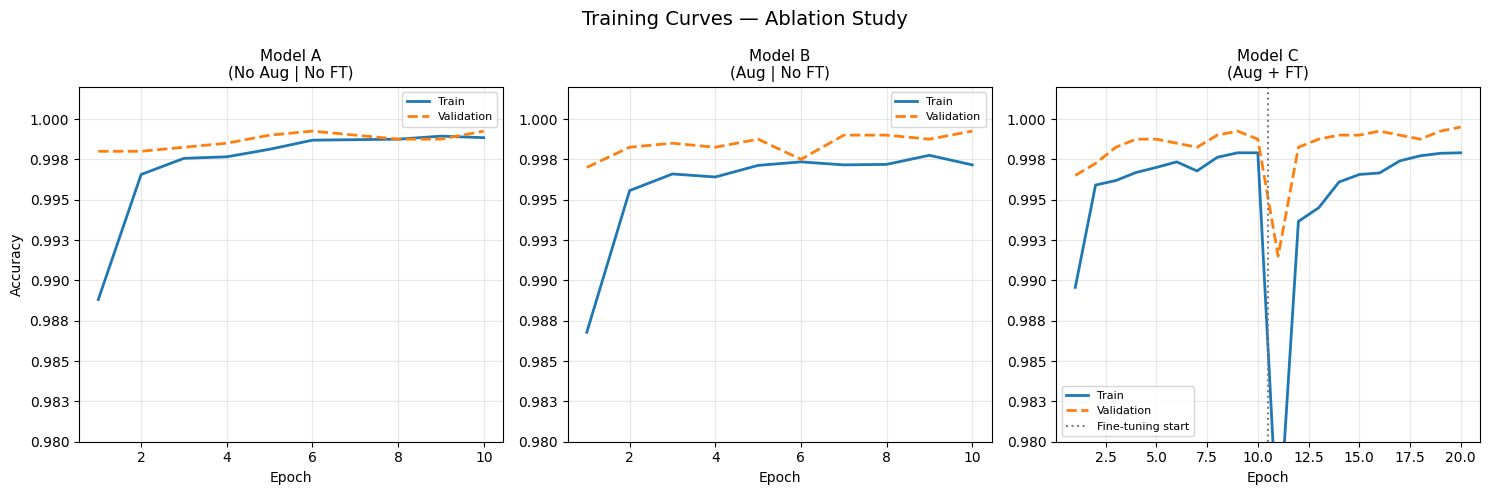

accuracy_curves.png salvo.


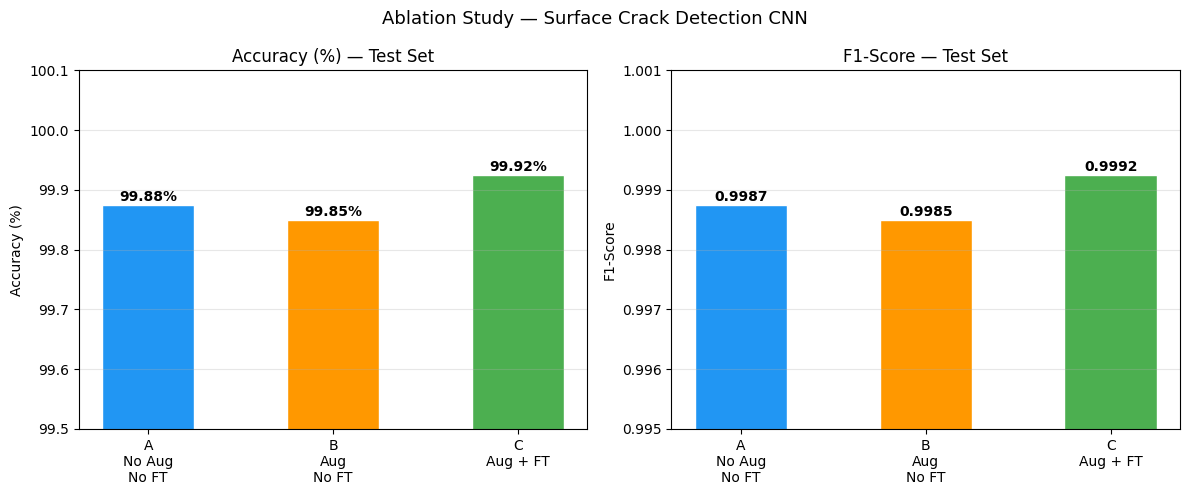

ablation_comparativo.png salvo.


In [10]:
# ============================================================
# CÉLULA 9 — Ablation Study: tabelas e gráficos
# ============================================================

print("="*55)
print("  ABLATION STUDY — RESULTADOS")
print("="*55)

# ── Tabela completa — Test Set ────────────────────────────────
tabela_test = pd.DataFrame([
    {"Model": "A", "Aug.": "No",  "FT": "No",
     "Acc.(%)":    round(resultado_a["accuracy"]*100,    2),
     "Precision":  round(resultado_a["precision"],       4),
     "Sensitivity":round(resultado_a["sensitivity"],     4),
     "Specificity":round(resultado_a["specificity"],     4),
     "F1":         round(resultado_a["f1"],              4)},
    {"Model": "B", "Aug.": "Yes", "FT": "No",
     "Acc.(%)":    round(resultado_b["accuracy"]*100,    2),
     "Precision":  round(resultado_b["precision"],       4),
     "Sensitivity":round(resultado_b["sensitivity"],     4),
     "Specificity":round(resultado_b["specificity"],     4),
     "F1":         round(resultado_b["f1"],              4)},
    {"Model": "C", "Aug.": "Yes", "FT": "Yes",
     "Acc.(%)":    round(resultado_c["accuracy"]*100,    2),
     "Precision":  round(resultado_c["precision"],       4),
     "Sensitivity":round(resultado_c["sensitivity"],     4),
     "Specificity":round(resultado_c["specificity"],     4),
     "F1":         round(resultado_c["f1"],              4)},
])

print("\n── Test Set ─────────────────────────────────────────")
print(tabela_test.to_string(index=False))
tabela_test.to_csv(os.path.join(PASTA_SAIDA, "ablation_test.csv"),
                   index=False, encoding="utf-8-sig")

# ── Ablation Study — Validation Set ──────────────────────────
acc_c = resultado_c_val["accuracy"] * 100
acc_b = resultado_b_val["accuracy"] * 100
acc_a = resultado_a_val["accuracy"] * 100
f1_c  = resultado_c_val["f1"]
f1_b  = resultado_b_val["f1"]
f1_a  = resultado_a_val["f1"]

tabela_val = pd.DataFrame([
    {"Configuration":  "Full model (Aug + FT)",
     "Val. Acc. (%)":  round(acc_c, 2),
     "F1":             round(f1_c,  4),
     "Δ Acc. (pp)":    "—",
     "Δ F1":           "—"},
    {"Configuration":  "Without fine-tuning (Aug only)",
     "Val. Acc. (%)":  round(acc_b, 2),
     "F1":             round(f1_b,  4),
     "Δ Acc. (pp)":    f"{round(acc_b - acc_c, 2):+.2f}",
     "Δ F1":           f"{round(f1_b  - f1_c,  4):+.4f}"},
    {"Configuration":  "Baseline (no Aug, no FT)",
     "Val. Acc. (%)":  round(acc_a, 2),
     "F1":             round(f1_a,  4),
     "Δ Acc. (pp)":    f"{round(acc_a - acc_c, 2):+.2f}",
     "Δ F1":           f"{round(f1_a  - f1_c,  4):+.4f}"},
])

print("\n── Ablation Study — Validation Set ─────────────────")
print(tabela_val.to_string(index=False))
tabela_val.to_csv(os.path.join(PASTA_SAIDA, "ablation_validation.csv"),
                  index=False, encoding="utf-8-sig")

# ── Relatório completo ────────────────────────────────────────
with open(os.path.join(PASTA_SAIDA, "ablation_relatorio.txt"), "w") as f:
    f.write("=== ABLATION STUDY — CRACK DETECTION ===\n\n")
    f.write("Versão definitiva — split\n")
    f.write(f"Dataset   : Surface Crack Detection (Kaggle)\n")
    f.write(f"Split     : 80/10/10 | Seed: {SEED} ")
    f.write(f"Treino    : {len(X_tr)} | Val: {len(X_val)} | Teste: {len(X_tst)}\n\n")
    f.write("── TEST SET ──\n")
    f.write(tabela_test.to_string(index=False))
    f.write("\n\n── ABLATION STUDY — VALIDATION SET ──\n")
    f.write(tabela_val.to_string(index=False))
    f.write("\n\n── RELATÓRIOS COMPLETOS ──\n")
    for res in [resultado_a, resultado_b, resultado_c,
                resultado_a_val, resultado_b_val, resultado_c_val]:
        f.write(f"\n{'─'*50}\n{res['nome']}\n{res['relatorio']}")

# ── Curvas de acurácia ───────────────────────────────────────────
def carregar_history(nome):
    with open(os.path.join(PASTA_SAIDA, nome)) as f:
        return json.load(f)

h_a  = carregar_history("history_A.json")
h_b  = carregar_history("history_B.json")
h_c1 = carregar_history("history_C1.json")
h_c2 = carregar_history("history_C2.json")

h_c = {
    "accuracy":     h_c1["accuracy"]     + h_c2["accuracy"],
    "val_accuracy": h_c1["val_accuracy"] + h_c2["val_accuracy"],
}
split_c = len(h_c1["accuracy"])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Training Curves — Ablation Study", fontsize=14)

configs = [
    (h_a,  "Model A\n(No Aug | No FT)", None),
    (h_b,  "Model B\n(Aug | No FT)",    None),
    (h_c,  "Model C\n(Aug + FT)",       split_c),
]

for col, (h, titulo, split) in enumerate(configs):
    epocas = range(1, len(h["accuracy"]) + 1)
    ax = axes[col]
    ax.plot(epocas, h["accuracy"],     label="Train",      linewidth=2)
    ax.plot(epocas, h["val_accuracy"], label="Validation",
            linewidth=2, linestyle="--")
    if split:
        ax.axvline(split + 0.5, color="gray", linestyle=":",
                   linewidth=1.5, label="Fine-tuning start")
    ax.set_title(titulo, fontsize=11)
    ax.set_ylabel("Accuracy" if col == 0 else "")
    ax.set_xlabel("Epoch")
    ax.set_ylim(0.980, 1.002)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f"{v:.3f}"))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PASTA_SAIDA, "accuracy_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("accuracy_curves.png salvo.")

# ── Gráfico de barras — Test Set ──────────────────────────────
resultados_tst = [resultado_a, resultado_b, resultado_c]
modelos = ["A\nNo Aug\nNo FT", "B\nAug\nNo FT", "C\nAug + FT"]
cores   = ["#2196F3", "#FF9800", "#4CAF50"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Ablation Study — Surface Crack Detection CNN", fontsize=13)

for ax, chave, titulo, ylabel, ylim in [
    (ax1, "accuracy", "Accuracy (%) — Test Set", "Accuracy (%)", (99.5, 100.1)),
    (ax2, "f1",       "F1-Score — Test Set",     "F1-Score",     (0.995, 1.001)),
]:
    vals    = [r[chave] for r in resultados_tst]
    plotvals= [v*100 if chave=="accuracy" else v for v in vals]
    bars    = ax.bar(modelos, plotvals, color=cores,
                     edgecolor="white", width=0.5)
    ax.set_title(titulo); ax.set_ylabel(ylabel)
    ax.set_ylim(ylim); ax.grid(axis="y", alpha=0.3)
    for bar, v in zip(bars, vals):
        label = f"{v*100:.2f}%" if chave=="accuracy" else f"{v:.4f}"
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (ylim[1]-ylim[0])*0.01,
                label, ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(PASTA_SAIDA, "ablation_comparativo.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("ablation_comparativo.png salvo.")


Calculando Grad-CAM para Positive corretos...
Calculando Grad-CAM para Negative corretos...


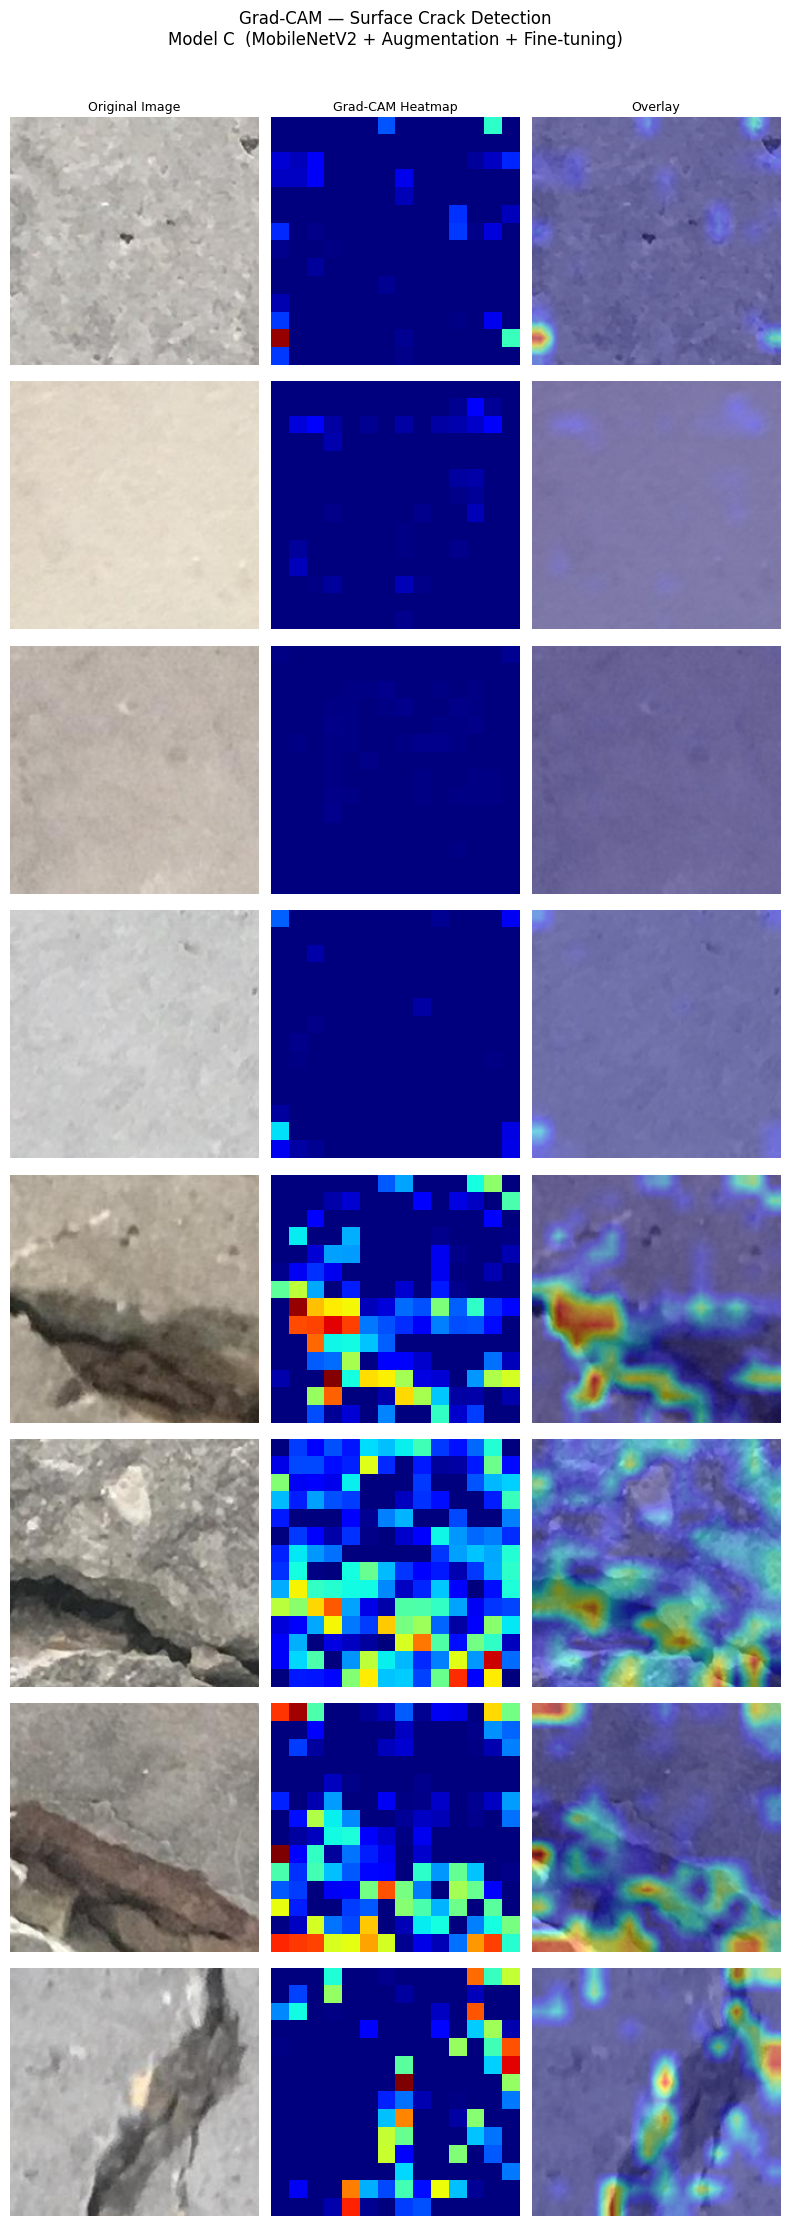

Grad-CAM.png salvo.


In [11]:
# ============================================================
# CÉLULA 10 — Grad-CAM (layout vertical 3x8)
# ============================================================

def gerar_gradcam(modelo, img_array, camadas_candidatas=None):
    if camadas_candidatas is None:
        camadas_candidatas = [
            "block_13_expand_relu",
            "block_12_expand_relu",
            "block_11_expand_relu",
        ]
    backbone = next(
        l for l in modelo.layers if isinstance(l, tf.keras.Model))
    nomes = {l.name for l in backbone.layers}
    camada_alvo = next(
        (c for c in camadas_candidatas if c in nomes), None)
    if camada_alvo is None:
        raise ValueError("Nenhuma camada candidata encontrada.")

    grad_model = tf.keras.models.Model(
        inputs=backbone.input,
        outputs=[backbone.get_layer(camada_alvo).output,
                 backbone.output]
    )
    gap_layer    = next(l for l in modelo.layers
                        if isinstance(l, tf.keras.layers.GlobalAveragePooling2D))
    dense_layers = [l for l in modelo.layers
                    if isinstance(l, tf.keras.layers.Dense)]
    dropout_layer= next(l for l in modelo.layers
                        if isinstance(l, tf.keras.layers.Dropout))
    dense_hidden = dense_layers[0]
    dense_output = dense_layers[1]

    with tf.GradientTape() as tape:
        img_tensor = tf.cast(img_array, tf.float32)
        conv_out, bb_out = grad_model(img_tensor)
        tape.watch(conv_out)
        x = gap_layer(bb_out)
        x = dense_hidden(x)
        x = dropout_layer(x, training=False)
        preds = dense_output(x)
        pred_idx = int(tf.argmax(preds[0]))
        loss = preds[:, pred_idx]

    grads   = tape.gradient(loss, conv_out)
    pooled  = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_out[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), pred_idx, preds.numpy()[0]

def sobrepor_gradcam(img_original, heatmap, alpha=0.45):
    h, w    = img_original.shape[:2]
    hm_res  = cv2.resize(heatmap, (w, h))
    hm_col  = cm.jet(hm_res)[:, :, :3]
    overlay = (1 - alpha) * img_original + alpha * hm_col
    return np.clip(overlay, 0, 1)

def score_heatmap(heatmap, threshold=0.5):
    return float(np.mean(heatmap > threshold))

def carregar_imagem(caminho):
    img = Image.open(caminho).convert("RGB")
    img = img.resize((TAMANHO_IMAGEM, TAMANHO_IMAGEM))
    return np.array(img, dtype=np.float32) / 255.0

# Positive — 4 com maior score de ativação
print("Calculando Grad-CAM para Positive corretos...")
idx_pos = [i for i in range(len(y_tst))
           if y_tst[i] == 1 and resultado_c["y_pred"][i] == 1]

resultados_pos = []
for idx in idx_pos:
    img_arr   = carregar_imagem(X_tst[idx])
    heatmap, pred_idx, probs = gerar_gradcam(modelo_c, img_arr[np.newaxis])
    resultados_pos.append({
        "img_arr": img_arr, "heatmap": heatmap,
        "pred_idx": pred_idx, "probs": probs,
        "score": score_heatmap(heatmap)
    })
resultados_pos.sort(key=lambda x: x["score"], reverse=True)
melhores_pos = resultados_pos[:4]

# Negative — 4 aleatórios corretos
print("Calculando Grad-CAM para Negative corretos...")
np.random.seed(SEED)
idx_neg = [i for i in range(len(y_tst))
           if y_tst[i] == 0 and resultado_c["y_pred"][i] == 0]
idx_neg_sel = np.random.choice(idx_neg, 4, replace=False)

melhores_neg = []
for idx in idx_neg_sel:
    img_arr   = carregar_imagem(X_tst[idx])
    heatmap, pred_idx, probs = gerar_gradcam(modelo_c, img_arr[np.newaxis])
    melhores_neg.append({
        "img_arr": img_arr, "heatmap": heatmap,
        "pred_idx": pred_idx, "probs": probs,
        "score": score_heatmap(heatmap)
    })

# Figura vertical 3 colunas x 8 linhas
grupos   = [("Negative", melhores_neg), ("Positive", melhores_pos)]
col_lbls = ["Original Image", "Grad-CAM Heatmap", "Overlay"]

fig, axes = plt.subplots(8, 3, figsize=(8, 22))
fig.suptitle(
    "Grad-CAM — Surface Crack Detection\n"
    "Model C  (MobileNetV2 + Augmentation + Fine-tuning)",
    fontsize=12, y=1.01
)

row = 0
for grupo_nome, amostras in grupos:
    for res in amostras:
        overlay = sobrepor_gradcam(res["img_arr"], res["heatmap"])
        conf    = res["probs"][res["pred_idx"]] * 100

        for col_idx, (img, cmap) in enumerate([
            (res["img_arr"], None),
            (res["heatmap"], "jet"),
            (overlay,        None),
        ]):
            ax = axes[row, col_idx]
            ax.imshow(img, cmap=cmap, vmin=0, vmax=1) if cmap else ax.imshow(img)
            ax.axis("off")

            # Títulos de coluna apenas na primeira linha
            if row == 0:
                ax.set_title(col_lbls[col_idx], fontsize=9, pad=4)

        # Rótulo da classe na margem esquerda
        axes[row, 0].set_ylabel(
            f"{grupo_nome}\n({conf:.1f}%)",
            fontsize=8, rotation=0,
            labelpad=60, va="center"
        )
        row += 1

plt.tight_layout()
plt.savefig(os.path.join(PASTA_SAIDA, "Grad-CAM.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Grad-CAM.png salvo.")


In [12]:
# ============================================================
# CÉLULA 11 — Download de todos os arquivos
# ============================================================

from google.colab import files

arquivos = [
    "ablation_relatorio.txt",
    "ablation_test.csv",
    "ablation_validation.csv",
    "history_A.json",
    "history_B.json",
    "history_C1.json",
    "history_C2.json",
    "accuracy_curves.png",
    "ablation_comparativo.png",
    "Grad-CAM.png",
    "modelo_a.keras",
    "modelo_b.keras",
    "modelo_c_final.keras",
]

print("Arquivos gerados:")
for nome in arquivos:
    caminho = os.path.join(PASTA_SAIDA, nome)
    existe  = os.path.exists(caminho)
    print(f"  {'✓' if existe else '✗'} {nome}")
    if existe:
        files.download(caminho)


Arquivos gerados:
  ✓ ablation_relatorio.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ ablation_test.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ modelo_c_final.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>